In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ethiopia.csv')

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [2]:
# Missing values report
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent.round(2)
})

print(missing_report[missing_report['Missing Count'] > 0])

if missing_report[missing_report['Missing Count'] > 0].empty:
    print("\n✅ No missing values found!")

MISSING VALUES REPORT
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

✅ No missing values found!


In [3]:
# Distribution overview
print("\n" + "=" * 50)
print("DISTRIBUTION OVERVIEW")
print("=" * 50)

key_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
print(df[key_vars].describe().round(2))


DISTRIBUTION OVERVIEW
           T2M  T2M_MAX  T2M_MIN  PRECTOTCORR     RH2M
count  4108.00  4108.00  4108.00      4108.00  4108.00
mean     16.07    23.20    10.23         3.63    68.41
std       1.90     2.75     2.61         6.29    14.74
min      10.03    15.65     1.17         0.00    14.42
25%      14.82    21.11     8.42         0.02    59.03
50%      16.04    22.74    10.99         0.82    71.12
75%      17.36    25.17    12.22         4.58    80.80
max      21.53    30.93    15.68        82.30    91.93


In [4]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset has 4108 rows and 12 columns

Column names:
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

Data types:
YEAR             int64
DOY              int64
T2M            float64
T2M_MAX        float64
T2M_MIN        float64
T2M_RANGE      float64
PRECTOTCORR    float64
RH2M           float64
WS2M           float64
WS2M_MAX       float64
PS             float64
QV2M           float64
dtype: object


In [5]:
df = df.replace(-999, np.nan)

print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [6]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

Number of duplicate rows: 0
Rows after removing duplicates: 4108


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [8]:
df['Country'] = 'Ethiopia'

In [9]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')

In [10]:
df['Month'] = df['Date'].dt.month

In [11]:
df[['YEAR', 'DOY', 'Date', 'Month', 'Country']].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Ethiopia
1,2015,2,2015-01-02,1,Ethiopia
2,2015,3,2015-01-03,1,Ethiopia
3,2015,4,2015-01-04,1,Ethiopia
4,2015,5,2015-01-05,1,Ethiopia


In [12]:
df.columns.tolist()

['YEAR',
 'DOY',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Country',
 'Date',
 'Month']

In [13]:
df['Country'] = 'Ethiopia'

df.columns.tolist()

['YEAR',
 'DOY',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Country',
 'Date',
 'Month']

In [14]:
df[['YEAR', 'DOY', 'Date', 'Month', 'Country']].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Ethiopia
1,2015,2,2015-01-02,1,Ethiopia
2,2015,3,2015-01-03,1,Ethiopia
3,2015,4,2015-01-04,1,Ethiopia
4,2015,5,2015-01-05,1,Ethiopia


In [15]:
print(f"Data from: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total months: {df['Month'].nunique()}")
print(f"Countries: {df['Country'].unique()}")

Data from: 2015-01-01 00:00:00 to 2026-03-31 00:00:00
Total months: 12
Countries: <StringArray>
['Ethiopia']
Length: 1, dtype: str


In [16]:
missing_pct = (df.isna().sum() / len(df)) * 100
print("Missing values percentage:")
print(missing_pct[missing_pct > 0])

Missing values percentage:
Series([], dtype: float64)


In [17]:
df[['YEAR', 'DOY', 'Date', 'Month', 'Country']].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Ethiopia
1,2015,2,2015-01-02,1,Ethiopia
2,2015,3,2015-01-03,1,Ethiopia
3,2015,4,2015-01-04,1,Ethiopia
4,2015,5,2015-01-05,1,Ethiopia


In [18]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers} outliers")

T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers


In [19]:
monthly_temp = df.groupby('Date')['T2M'].mean()

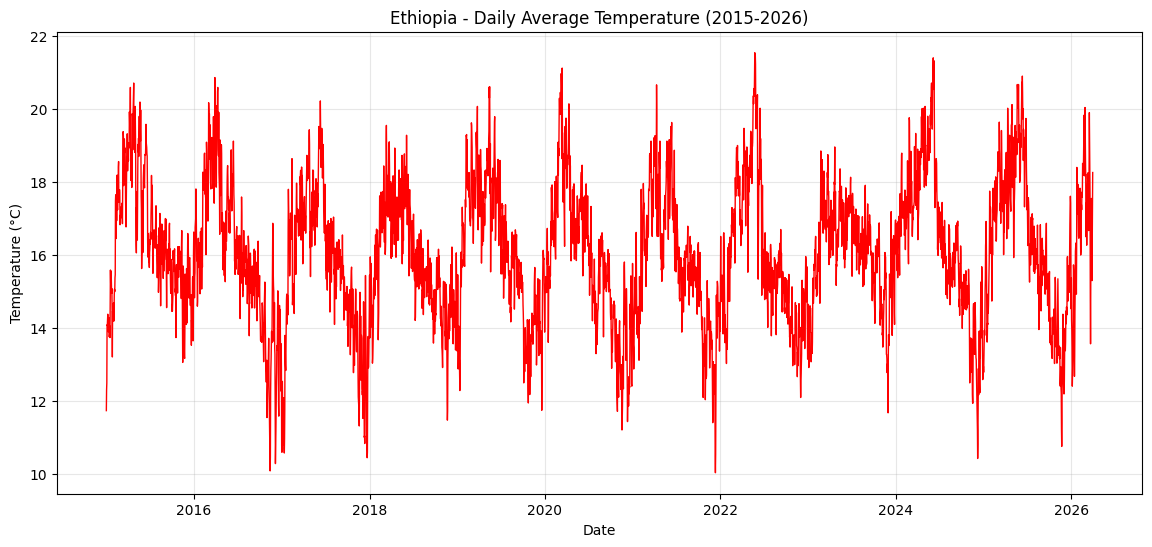

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='red', linewidth=1)
plt.title('Ethiopia - Daily Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

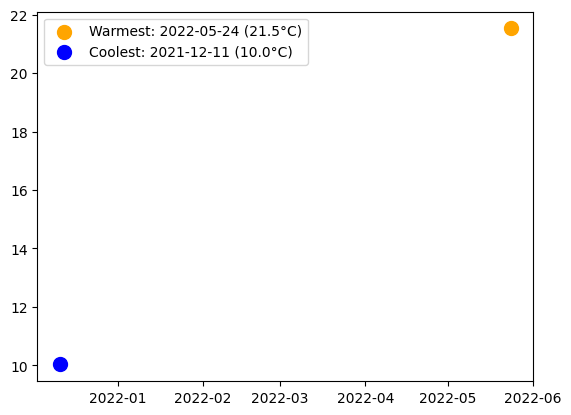

In [21]:
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(warmest, monthly_temp.max(), color='orange', s=100, label=f'Warmest: {warmest.date()} ({monthly_temp.max():.1f}°C)')
plt.scatter(coolest, monthly_temp.min(), color='blue', s=100, label=f'Coolest: {coolest.date()} ({monthly_temp.min():.1f}°C)')
plt.legend()
plt.show()

In [22]:
monthly_avg = df.groupby('Month')['T2M'].mean()

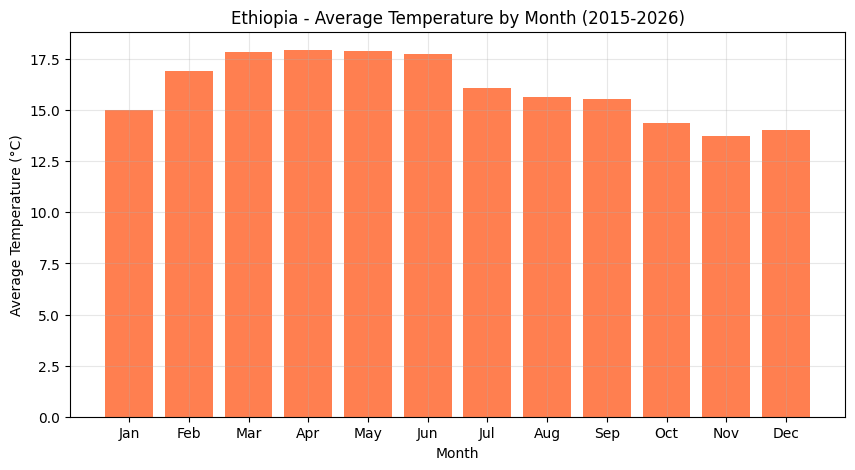

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Ethiopia - Average Temperature by Month (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
print(f"Warmest month: {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest month: {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")

Warmest month: 4 (17.9°C)
Coolest month: 11 (13.8°C)


In [25]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()

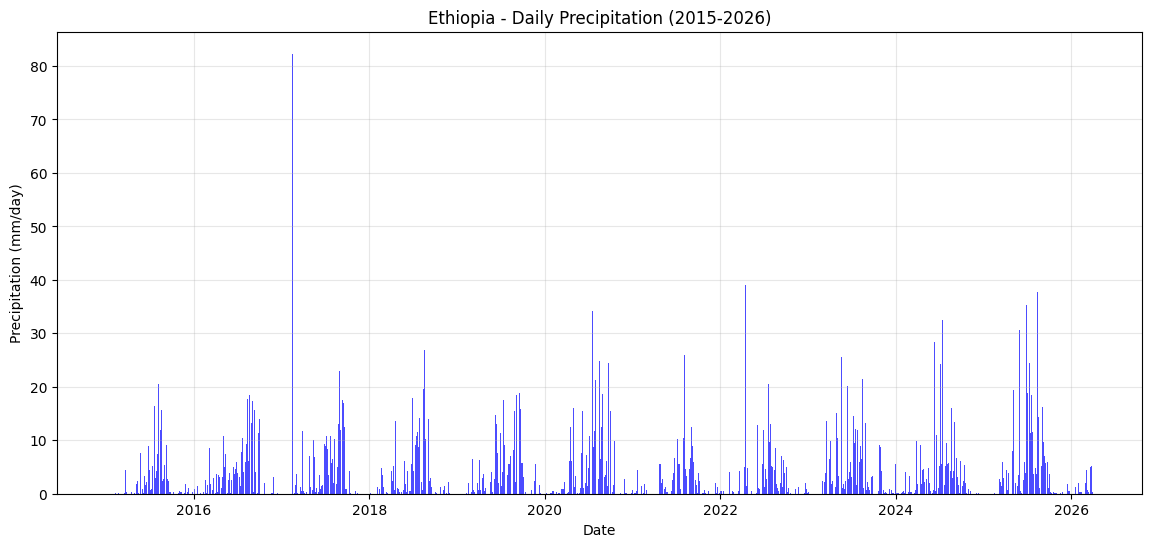

In [26]:
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Ethiopia - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[numeric_cols].corr()

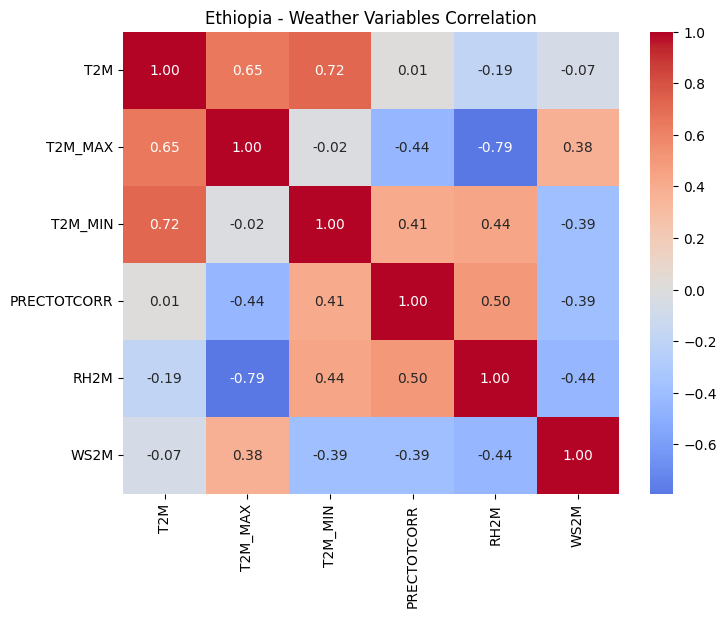

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ethiopia - Weather Variables Correlation')
plt.show()

In [29]:
print("Strongest correlations:")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_value:.2f}")

Strongest correlations:
T2M vs T2M_MAX: 0.65
T2M vs T2M_MIN: 0.72
T2M_MAX vs RH2M: -0.79
PRECTOTCORR vs RH2M: 0.50


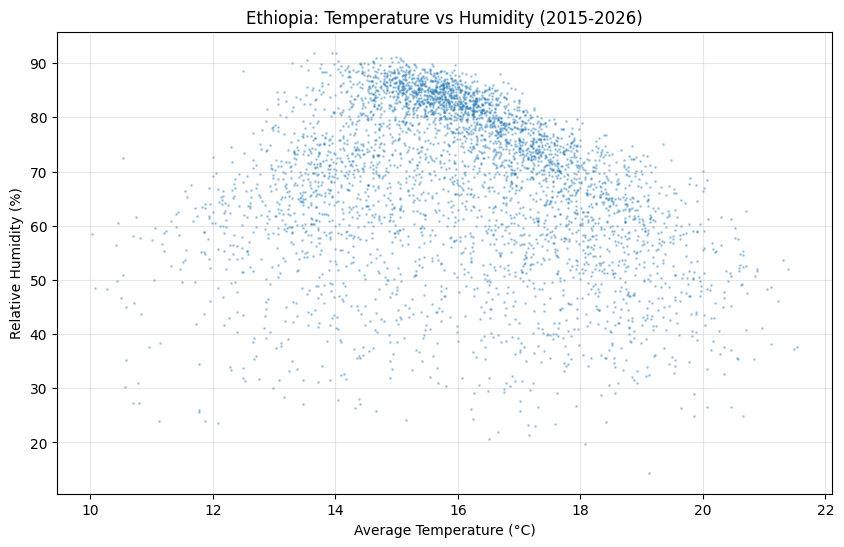

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: Temperature vs Humidity (2015-2026)')
plt.grid(True, alpha=0.3)
plt.show()

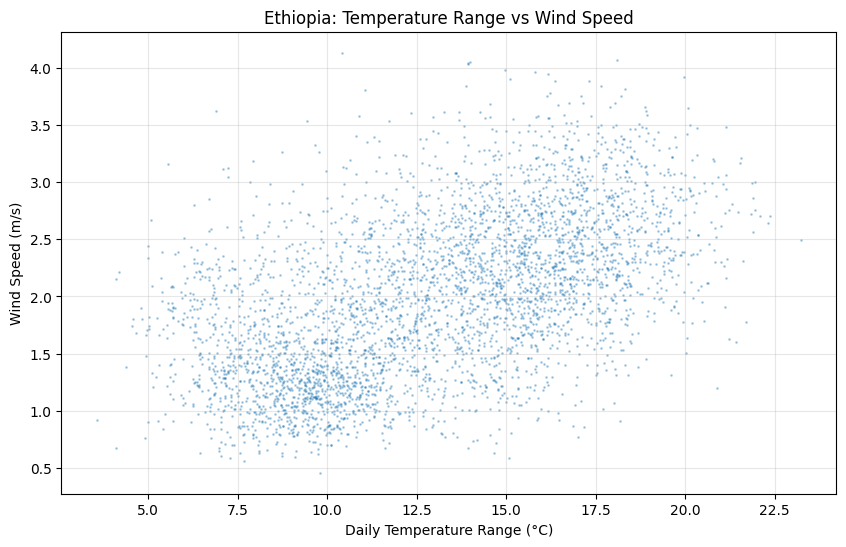

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Ethiopia: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
import numpy as np


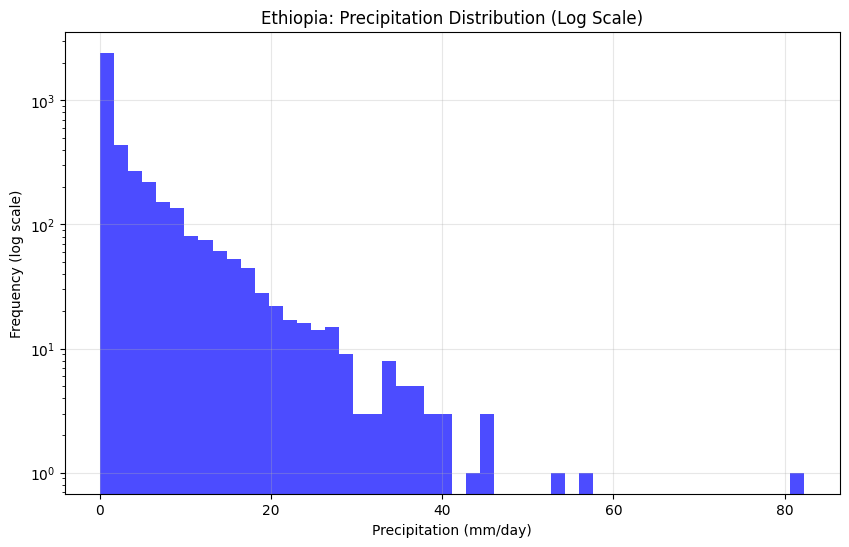

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Ethiopia: Precipitation Distribution (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

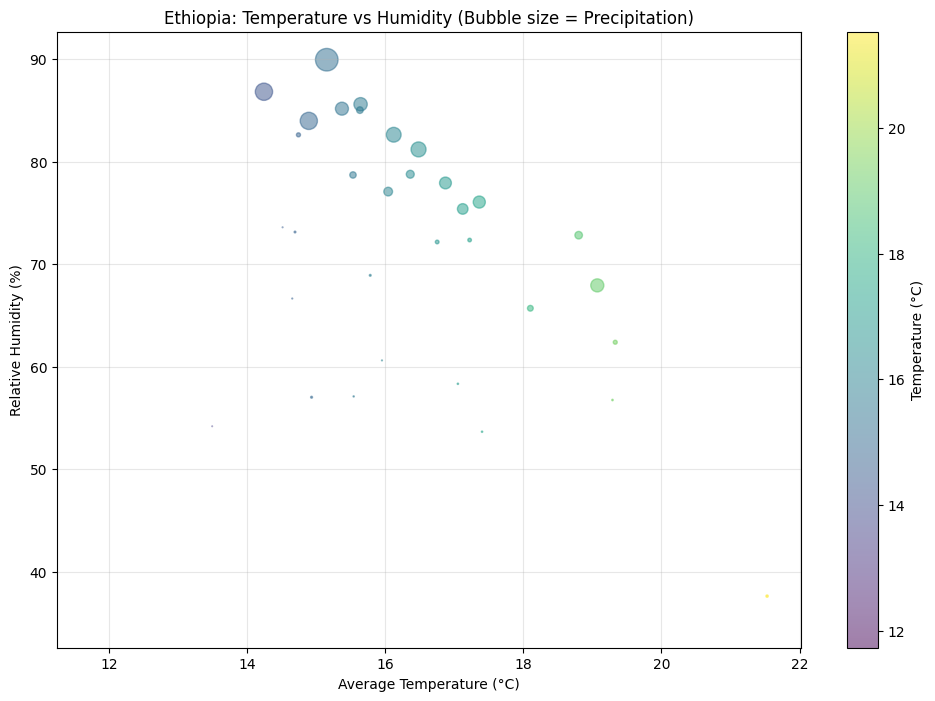

In [34]:
sample = df.iloc[::100, :]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR']*10,  # bubble size = precipitation
                      alpha=0.5, c=sample['T2M'], cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: Temperature vs Humidity (Bubble size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()